In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_excel('/content/drive/MyDrive/Data_Cabai.xlsx', header=1)

# ambil semua nilai tanpa kolom tahun
data = data.iloc[:, 1:].values.flatten()

# buang NaN
data = data[~pd.isna(data)]

# ubah ke numerik (handle string kayak '17000.1')
data = pd.to_numeric(data, errors='coerce')

# buang lagi NaN hasil convert
data = data[~np.isnan(data)]

# reshape ke format LSTM
data = data.reshape(-1, 1)

print("Total data:", len(data))

Total data: 226


In [ ]:
# -------------------------
# 2. SPLIT DATA (TIME SERIES)
# -------------------------
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data  = data[train_size:]


In [ ]:
# -------------------------
# 3. NORMALISASI (NO LEAKAGE)
# -------------------------
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

In [ ]:
window_size = 12

print("Total data:", len(data))
print("Train:", len(train_data))
print("Test:", len(test_data))
print("Window size:", window_size)

Total data: 226
Train: 180
Test: 46
Window size: 12


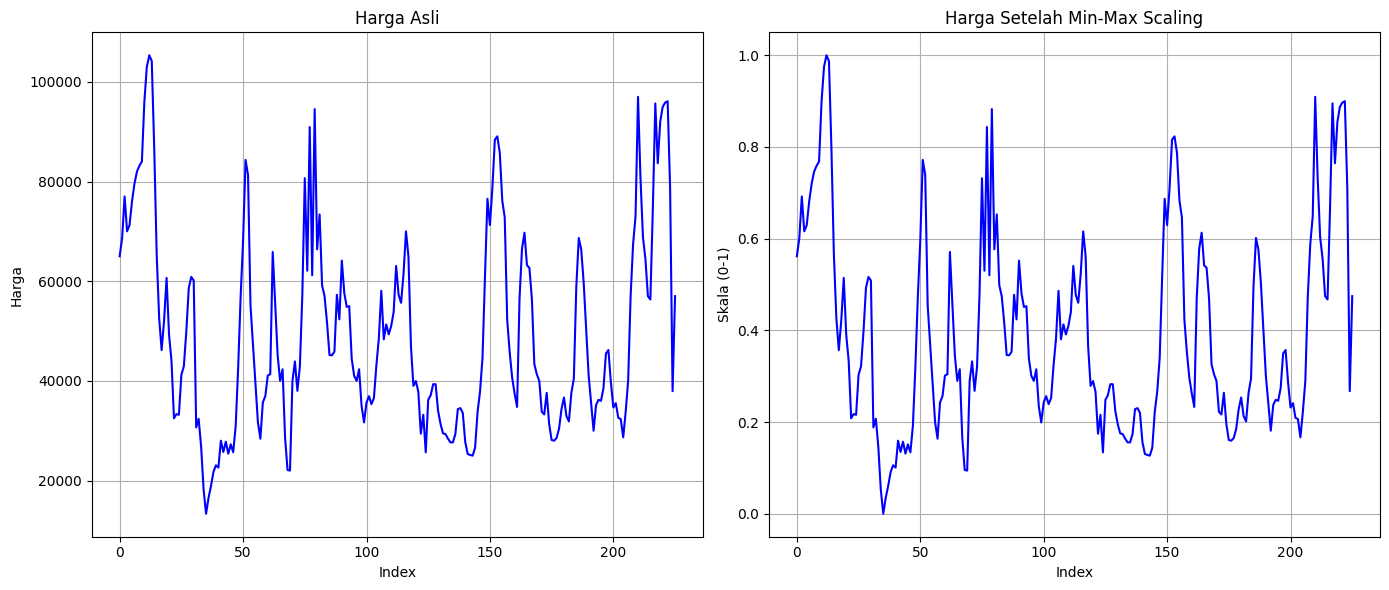

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# gabungkan normalized data
all_scaled_data = np.concatenate((train_scaled, test_scaled), axis=0)

plt.figure(figsize=(14, 6))

# -------------------------
# KIRI: DATA ASLI
# -------------------------
plt.subplot(1, 2, 1)
plt.plot(data, color='blue')
plt.title('Harga Asli')
plt.xlabel('Index')
plt.ylabel('Harga')
plt.grid(True)

# -------------------------
# KANAN: DATA NORMALIZED
# -------------------------
plt.subplot(1, 2, 2)
plt.plot(all_scaled_data, color='blue')
plt.title('Harga Setelah Min-Max Scaling')
plt.xlabel('Index')
plt.ylabel('Skala (0-1)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# -------------------------
# 4. CREATE DATASET (SINGLE STEP)
# -------------------------
def create_dataset(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])  # 1 step ahead
    return np.array(X), np.array(y)

window_size = 12

X_train, y_train = create_dataset(train_scaled, window_size)
X_test,  y_test  = create_dataset(test_scaled,  window_size)

# reshape ke format LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

y_train = y_train.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

In [ ]:
# -------------------------
# 5. BUILD MODEL (Dense 1)
# -------------------------
model = Sequential([
    LSTM(32, input_shape=(window_size, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mae')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# -------------------------
# 6. TRAINING
# -------------------------
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.3220 - val_loss: 0.3473
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1747 - val_loss: 0.1947
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1411 - val_loss: 0.1809
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1349 - val_loss: 0.1955
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1334 - val_loss: 0.2006
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1310 - val_loss: 0.1840
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1284 - val_loss: 0.1807
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1270 - val_loss: 0.1816
Epoch 9/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1250 - val_loss: 0.1775
Epoch 10/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1230 - val_loss: 0.1764
Epoch 11/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1214 - val_loss: 0.1733
Epoch 12/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

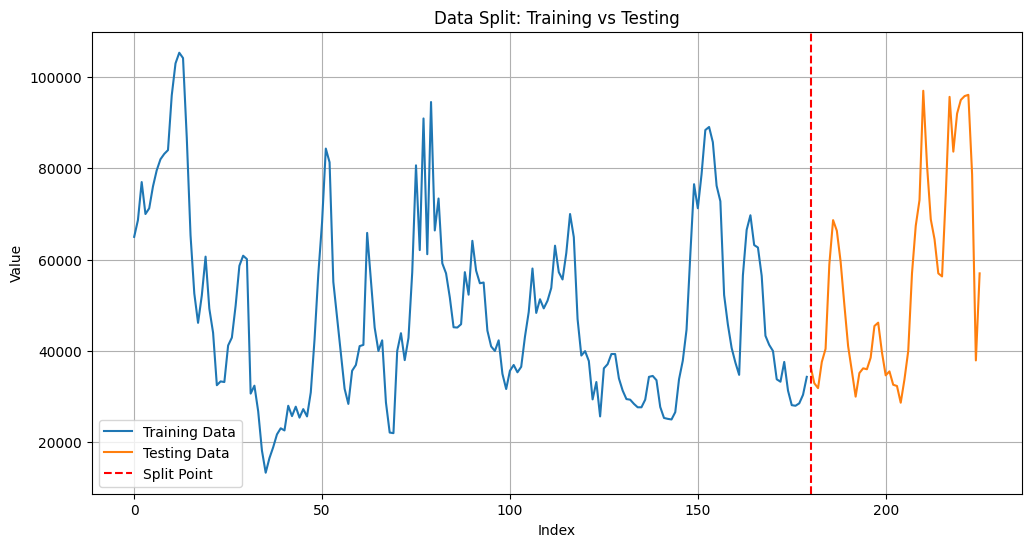

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(train_data)), train_data, label='Training Data')
plt.plot(np.arange(len(train_data), len(data)), test_data, label='Testing Data')
plt.axvline(x=len(train_data), color='red', linestyle='--', label='Split Point')
plt.title('Data Split: Training vs Testing')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# -------------------------
# 7. PREDIKSI
# -------------------------
pred_scaled = model.predict(X_test)

# inverse scaling
pred_actual = scaler.inverse_transform(pred_scaled)
y_test_actual = scaler.inverse_transform(y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step


In [ ]:
# -------------------------
# 8. EVALUASI
# -------------------------
rmse = np.sqrt(mean_squared_error(y_test_actual, pred_actual))
mape = np.mean(np.abs((y_test_actual - pred_actual) / y_test_actual)) * 100

print(f"\nRMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# tampilkan beberapa hasil
print("\nContoh prediksi vs aktual:")
for i in range(1):
    print(f"Pred: {pred_actual[i][0]:.0f} | Actual: {y_test_actual[i][0]:.0f}")


RMSE: 12100.73
MAPE: 15.24%

Contoh prediksi vs aktual:
Pred: 33448 | Actual: 30000


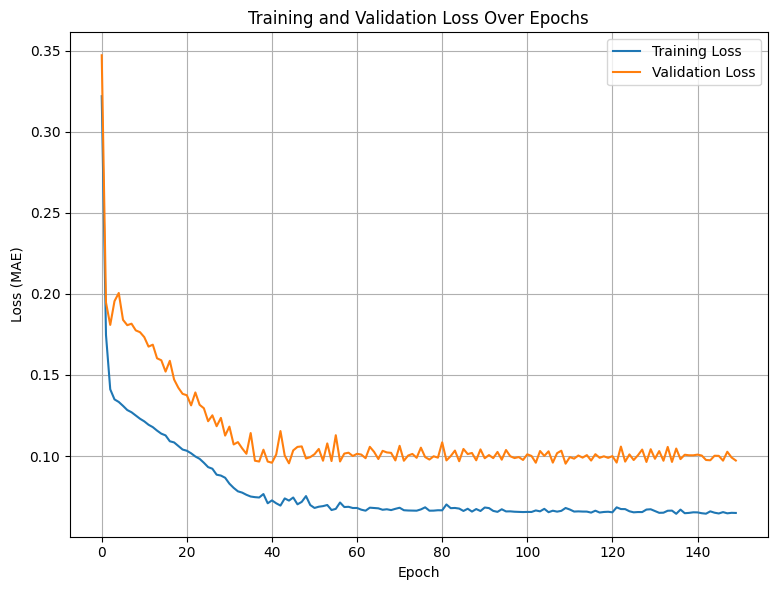

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# Subplot 1: Training dan Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

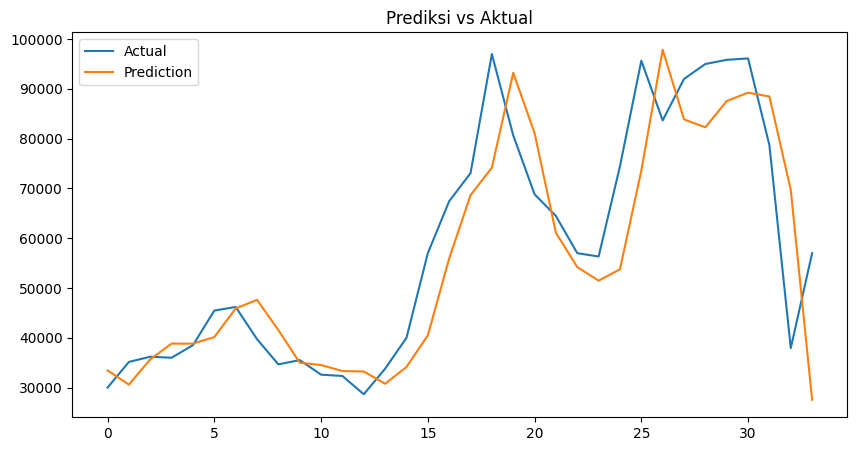

In [ ]:
# -------------------------
# 9. VISUALISASI
# -------------------------
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(pred_actual, label='Prediction')
plt.title('Prediksi vs Aktual')
plt.legend()
plt.show()

In [ ]:
# -------------------------
# 10. FORECAST 4 MINGGU (RECURSIVE)
# -------------------------
def forecast_next_steps(model, last_window, steps=4):
    preds = []
    current = last_window.copy()

    for _ in range(steps):
        pred = model.predict(current.reshape(1, -1, 1), verbose=0)[0][0]
        preds.append(pred)
        current = np.append(current[1:], pred)

    return np.array(preds)

In [ ]:
# ambil window terakhir dari test
last_window = test_scaled[-window_size:].flatten()

future_scaled = forecast_next_steps(model, last_window, steps=4)
future_actual = scaler.inverse_transform(future_scaled.reshape(-1,1))

print("\nPrediksi 4 minggu ke depan:")
for i, val in enumerate(future_actual):
    print(f"Minggu ke-{i+1}: {val[0]:.0f}")


Prediksi 4 minggu ke depan:
Minggu ke-1: 49677
Minggu ke-2: 56387
Minggu ke-3: 59868
Minggu ke-4: 61656


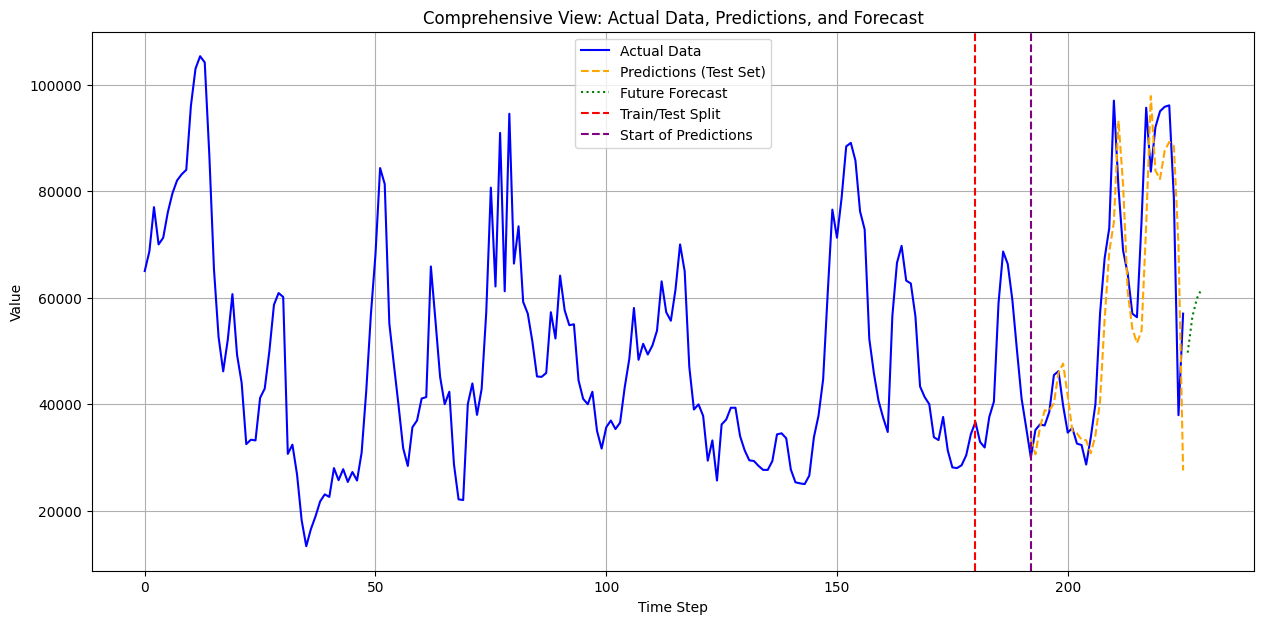

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 7))

# Plot the entire original data
plt.plot(np.arange(len(data)), data.flatten(), label='Actual Data', color='blue')

# Plot the predictions on the test set
# Predictions start after the training data and window size
plt.plot(np.arange(train_size + window_size, train_size + window_size + len(pred_actual)), pred_actual.flatten(), label='Predictions (Test Set)', color='orange', linestyle='--')

# Plot the future forecast
# Forecast starts after the entire actual data
plt.plot(np.arange(len(data), len(data) + len(future_actual)), future_actual.flatten(), label='Future Forecast', color='green', linestyle=':')

# Add vertical line for train/test split
plt.axvline(x=train_size, color='red', linestyle='--', label='Train/Test Split')

# Add vertical line for start of predictions
plt.axvline(x=train_size + window_size, color='purple', linestyle='--', label='Start of Predictions')

plt.title('Comprehensive View: Actual Data, Predictions, and Forecast')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

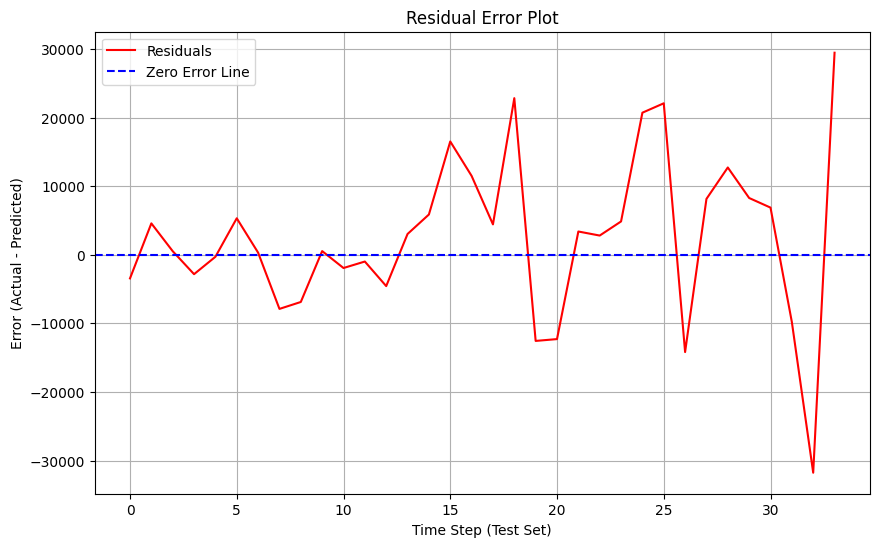

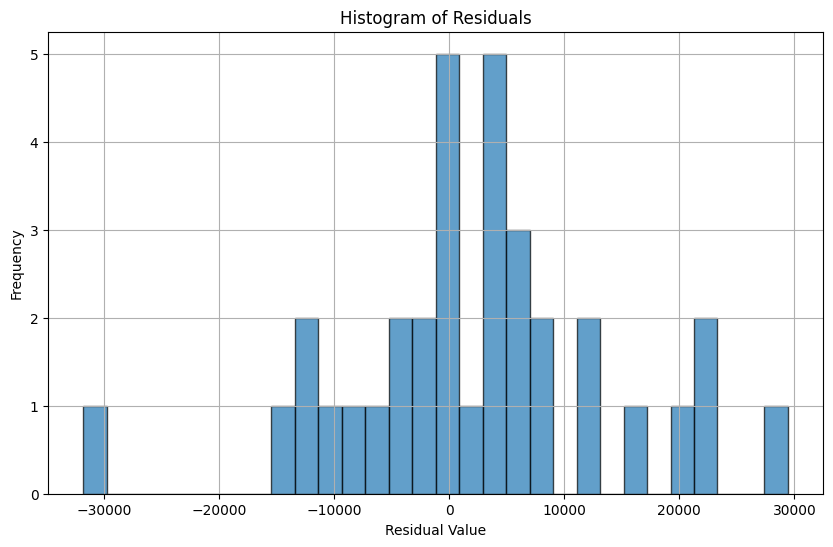

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate residuals
residuals = y_test_actual - pred_actual

plt.figure(figsize=(10, 6))
plt.plot(residuals, color='red', label='Residuals')
plt.axhline(y=0, color='blue', linestyle='--', label='Zero Error Line')
plt.title('Residual Error Plot')
plt.xlabel('Time Step (Test Set)')
plt.ylabel('Error (Actual - Predicted)')
plt.legend()
plt.grid(True)
plt.show()

# Optional: Histogram of residuals to check for normal distribution
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()